#  Da Regressão Linear à Otimização de Portfólio

## Objetivos
1. Revisar regressão linear como problema de otimização
2. Entender a conexão com teoria de portfólio
3. Implementar Markowitz do zero
4. Aplicar em dados reais

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


## 1. Regressão Linear: Um Problema de Otimização

Você já sabe que em regressão linear queremos encontrar $\beta$ que minimiza:

$$\min_{\beta} \sum_{i=1}^{n} (y_i - X_i\beta)^2$$

Ou em notação matricial:

$$\min_{\beta} (Y - X\beta)^T(Y - X\beta)$$

**Solução analítica (você conhece):**

$$\hat{\beta} = (X^TX)^{-1}X^TY$$

### Por que isso importa?
Portfólio é o mesmo conceito: **minimizar algo (risco) sujeito a restrições**!

Coeficientes estimados (esperado ≈ [2, 3]):
β₀ (intercepto) = 2.004
β₁ (slope) = 2.928


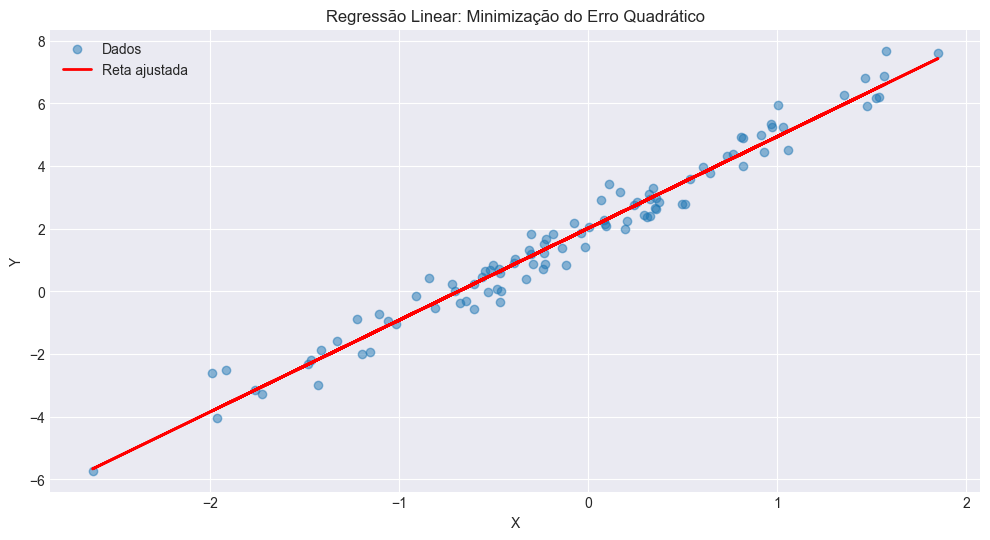

In [2]:
np.random.seed(42)

X = np.random.randn(100, 1)
X_com_intercepto = np.column_stack([np.ones(100), X])  # Adiciona coluna de 1s
y = 2 + 3*X + np.random.randn(100, 1) * 0.5

beta_hat = np.linalg.inv(X_com_intercepto.T @ X_com_intercepto) @ X_com_intercepto.T @ y

print("Coeficientes estimados (esperado ≈ [2, 3]):")
print(f"β₀ (intercepto) = {beta_hat[0, 0]:.3f}")
print(f"β₁ (slope) = {beta_hat[1, 0]:.3f}")

plt.scatter(X, y, alpha=0.5, label='Dados')
plt.plot(X, X_com_intercepto @ beta_hat, 'r-', linewidth=2, label='Reta ajustada')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.title('Regressão Linear: Minimização do Erro Quadrático')
plt.show()

## 2. A Ponte: De Regressão para Portfólios

### Comparando os dois problemas:

| | Regressão Linear | Portfólio de Markowitz |
|---|---|---|
| **Variável de decisão** | $\beta$ (coeficientes) | $w$ (pesos dos ativos) |
| **Objetivo** | Minimizar erro quadrático | Minimizar risco (variância) |
| **Restrição** | Nenhuma (OLS puro) | $\sum w_i = 1$ (investir tudo) |
| **Solução** | Analítica $(X^TX)^{-1}X^TY$ | Numérica (otimizador) |

### O problema de Markowitz:

$$\min_{w} \quad w^T \Sigma w \quad \text{(minimizar variância do portfólio)}$$

$$\text{sujeito a:} \quad w^T \mathbf{1} = 1 \quad \text{(pesos somam 100\%)}$$

$$w^T \mu \geq \mu_{\text{alvo}} \quad \text{(retorno mínimo desejado)}$$

$$w_i \geq 0 \quad \text{(sem venda a descoberto)}$$

### Onde:
- $w$ = vetor de pesos (quanto investir em cada ativo)
- $\Sigma$ = matriz de covariância dos retornos
- $\mu$ = vetor de retornos esperados
- $w^T \Sigma w$ = variância do portfólio (risco!)

## 3. Intuição: Matriz de Covariância

 **CONCEITO MATEMÁTICO: Matriz de Covariância $\Sigma$**

Para $n$ ativos, $\Sigma$ é uma matriz $n \times n$ onde:

$$\Sigma_{ij} = Cov(R_i, R_j) = E[(R_i - \mu_i)(R_j - \mu_j)]$$

**Exemplo com 3 ativos:**

$$\Sigma = \begin{pmatrix} \sigma_1^1 & \sigma_{12} & \sigma_{13} \\ \sigma_{21} & \sigma_2^2 & \sigma_{23} \\ \sigma_{31} & \sigma_{32} & \sigma_3^2 \end{pmatrix}$$

- **Diagonal** ($\sigma_i^2$): variância de cada ativo (risco individual)
- **Fora da diagonal** ($\sigma_{ij}$): covariância entre ativos

**Por que isso importa para diversificação?**

$$Var(\text{portfólio}) = w^T \Sigma w = \sum_i w_i^2 \sigma_i^2 + 2\sum_{i<j} w_i w_j \sigma_{ij}$$

Se $\sigma_{ij} < 0$ (ativos negativamente correlacionados), a variância do portfólio **diminui!**
Isso é a essência da **diversificação**!

In [3]:
np.random.seed(42)
n_dias = 252  # 1 ano de pregões

retornos = np.random.multivariate_normal(
    mean=[0.10/252, 0.15/252, 0.08/252],          # Retornos diários médios
    cov=[[0.20**2/252, 0.5*0.20*0.30/252, -0.2*0.20*0.15/252],   # Covariâncias
         [0.5*0.20*0.30/252, 0.30**2/252, -0.1*0.30*0.15/252],
         [-0.2*0.20*0.15/252, -0.1*0.30*0.15/252, 0.15**2/252]],
    size=n_dias
)

df_retornos = pd.DataFrame(retornos, columns=['Ativo_1', 'Ativo_2', 'Ativo_3'])

# Calcular retornos anualizados e matriz de covariância
mu = df_retornos.mean() * 252 
Sigma = df_retornos.cov() * 252

print("RETORNOS ESPERADOS ANUAIS:")
for ativo, ret in mu.items():
    print(f"  {ativo}: {ret:.1%}")

print("\nMATRIZ DE COVARIÂNCIA ANUALIZADA:")
print(Sigma.round(4))

print("\nMATRIZ DE CORRELAÇÃO:")
print(df_retornos.corr().round(3))

print("\nO Ativo_3 tem correlação NEGATIVA com os outros!")
print("   Quando 1 e 2 caem, 3 tende a subir.")
print("   = DIVERSIFICAÇÃO!")

RETORNOS ESPERADOS ANUAIS:
  Ativo_1: -29.5%
  Ativo_2: 2.4%
  Ativo_3: 36.8%

MATRIZ DE COVARIÂNCIA ANUALIZADA:
         Ativo_1  Ativo_2  Ativo_3
Ativo_1   0.0348   0.0221  -0.0043
Ativo_2   0.0221   0.0742  -0.0008
Ativo_3  -0.0043  -0.0008   0.0253

MATRIZ DE CORRELAÇÃO:
         Ativo_1  Ativo_2  Ativo_3
Ativo_1    1.000    0.434   -0.146
Ativo_2    0.434    1.000   -0.019
Ativo_3   -0.146   -0.019    1.000

O Ativo_3 tem correlação NEGATIVA com os outros!
   Quando 1 e 2 caem, 3 tende a subir.
   = DIVERSIFICAÇÃO!


## 4. Calculando Risco e Retorno de um Portfólio

### Fórmulas fundamentais:

**Retorno do portfólio** (linear nos pesos):
$$R_p = w^T \mu = \sum_{i=1}^{n} w_i \mu_i$$

**Variância do portfólio** (quadrática nos pesos):
$$\sigma_p^2 = w^T \Sigma w = \sum_{i=1}^{n} \sum_{j=1}^{n} w_i w_j \sigma_{ij}$$

**Desvio padrão do portfólio** (volatilidade):
$$\sigma_p = \sqrt{w^T \Sigma w}$$

### Exemplo numérico:
Se investimos 40% no Ativo 1, 30% no Ativo 2 e 30% no Ativo 3:
- Retorno esperado é simples: $0.4 \times 10\% + 0.3 \times 15\% + 0.3 \times 8\%$
- Mas o risco **NÃO é** $0.4 \times 20\% + 0.3 \times 30\% + 0.3 \times 15\%$
- O risco considera as **covariâncias**! Por isso diversificação funciona.

In [4]:
"""
📐 CONCEITO: Funções para calcular métricas de portfólio
   Vamos criar funções reutilizáveis que usaremos no otimizador
"""

def retorno_portfolio(w, mu):
    """
    Calcula o retorno esperado do portfólio
    
    Parâmetros:
    - w: array com pesos dos ativos (soma = 1)
    - mu: array com retornos esperados
    
    Retorna: float (retorno do portfólio)
    
    Matemática: w^T * μ (produto interno)
    """
    return w @ mu  # Equivalente a np.dot(w, mu)


def volatilidade_portfolio(w, Sigma):
    """
    Calcula a volatilidade (desvio padrão) do portfólio
    
    Parâmetros:
    - w: array com pesos dos ativos
    - Sigma: matriz de covariância
    
    Retorna: float (volatilidade do portfólio)
    
    Matemática: σ_p = √(w^T Σ w)
    """
    variancia = w @ Sigma @ w  # Forma quadrática w^T Σ w
    return np.sqrt(variancia)


def sharpe_ratio(w, mu, Sigma, rf=0.02):
    """
    Calcula o Sharpe Ratio do portfólio
    
    Sharpe Ratio = (Retorno - Taxa livre de risco) / Volatilidade
    Mede quanto de retorno você ganha por unidade de risco
    
    Parâmetros:
    - w: pesos
    - mu: retornos esperados
    - Sigma: matriz de covariância
    - rf: taxa livre de risco (default 2% a.a.)
    
    Retorna: float (quanto maior, melhor!)
    """
    ret = retorno_portfolio(w, mu)
    vol = volatilidade_portfolio(w, Sigma)
    return (ret - rf) / vol


print("✅ Funções de portfólio criadas!")
print("\nFunções disponíveis:")
print("  • retorno_portfolio(w, mu)")
print("  • volatilidade_portfolio(w, Sigma)")
print("  • sharpe_ratio(w, mu, Sigma, rf)")

✅ Funções de portfólio criadas!

Funções disponíveis:
  • retorno_portfolio(w, mu)
  • volatilidade_portfolio(w, Sigma)
  • sharpe_ratio(w, mu, Sigma, rf)


In [5]:
"""
Vamos testar 4 portfólios diferentes e ver como diversificação afeta o risco
"""

# Definir 4 estratégias diferentes
portfolios = {
    'Concentrado em 1': np.array([1.0, 0.0, 0.0]),      # 100% no Ativo 1
    'Concentrado em 2': np.array([0.0, 1.0, 0.0]),      # 100% no Ativo 2  
    'Concentrado em 3': np.array([0.0, 0.0, 1.0]),      # 100% no Ativo 3
    'Igualmente distribuído': np.array([1/3, 1/3, 1/3]), # 33.3% em cada
    'Balanceado': np.array([0.4, 0.3, 0.3]),            # 40%, 30%, 30%
}

print("="*70)
print("COMPARAÇÃO DE PORTFÓLIOS")
print("="*70)

resultados = []

for nome, w in portfolios.items():
    ret = retorno_portfolio(w, mu)
    vol = volatilidade_portfolio(w, Sigma)
    sharpe = sharpe_ratio(w, mu, Sigma)
    
    resultados.append({
        'Portfólio': nome,
        'Retorno': ret,
        'Volatilidade': vol,
        'Sharpe': sharpe
    })
    
    print(f"\n📊 {nome}")
    print(f"   Pesos: {w}")
    print(f"   Retorno esperado: {ret:.2%}")
    print(f"   Volatilidade: {vol:.2%}")
    print(f"   Sharpe Ratio: {sharpe:.3f}")

print("\n" + "="*70)
print("💡 OBSERVAÇÕES:")
print("   • Ativo 2 tem maior retorno MAS também maior risco")
print("   • Portfólios diversificados reduzem risco sem perder muito retorno")
print("   • Sharpe Ratio indica qual portfólio é mais 'eficiente'")
print("="*70)

COMPARAÇÃO DE PORTFÓLIOS

📊 Concentrado em 1
   Pesos: [1. 0. 0.]
   Retorno esperado: -29.46%
   Volatilidade: 18.65%
   Sharpe Ratio: -1.687

📊 Concentrado em 2
   Pesos: [0. 1. 0.]
   Retorno esperado: 2.38%
   Volatilidade: 27.23%
   Sharpe Ratio: 0.014

📊 Concentrado em 3
   Pesos: [0. 0. 1.]
   Retorno esperado: 36.79%
   Volatilidade: 15.90%
   Sharpe Ratio: 2.188

📊 Igualmente distribuído
   Pesos: [0.33333333 0.33333333 0.33333333]
   Retorno esperado: 3.24%
   Volatilidade: 13.66%
   Sharpe Ratio: 0.091

📊 Balanceado
   Pesos: [0.4 0.3 0.3]
   Retorno esperado: -0.03%
   Volatilidade: 13.64%
   Sharpe Ratio: -0.149

💡 OBSERVAÇÕES:
   • Ativo 2 tem maior retorno MAS também maior risco
   • Portfólios diversificados reduzem risco sem perder muito retorno
   • Sharpe Ratio indica qual portfólio é mais 'eficiente'


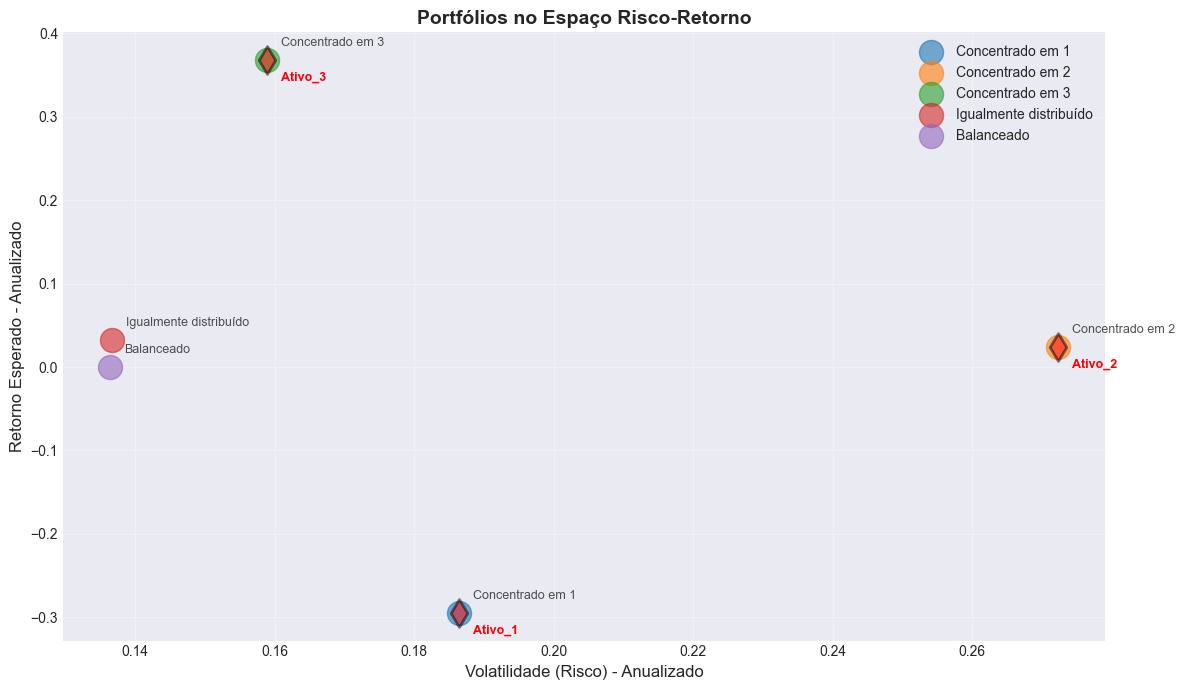


💡 O que observar no gráfico:
   • Losangos vermelhos = ativos individuais
   • Círculos = portfólios (combinações de ativos)
   • Note que alguns portfólios têm MENOS risco que qualquer ativo individual!
   • Isso é o poder da diversificação! 🎯


In [6]:
"""
📊 Vamos plotar esses portfólios no espaço risco-retorno
"""

# Extrair dados para o gráfico
df_resultados = pd.DataFrame(resultados)

plt.figure(figsize=(12, 7))

# Plotar cada portfólio
for i, row in df_resultados.iterrows():
    plt.scatter(row['Volatilidade'], row['Retorno'], 
               s=300, alpha=0.6, label=row['Portfólio'])
    plt.annotate(row['Portfólio'], 
                xy=(row['Volatilidade'], row['Retorno']),
                xytext=(10, 10), textcoords='offset points',
                fontsize=9, alpha=0.8)

# Plotar também os ativos individuais
for i, ativo in enumerate(['Ativo_1', 'Ativo_2', 'Ativo_3']):
    vol_ativo = np.sqrt(Sigma.iloc[i, i])  # Diagonal da matriz = variância individual
    ret_ativo = mu.iloc[i]
    plt.scatter(vol_ativo, ret_ativo, marker='d', s=200, 
               c='red', alpha=0.5, edgecolors='black', linewidths=2)
    plt.annotate(ativo, xy=(vol_ativo, ret_ativo),
                xytext=(10, -15), textcoords='offset points',
                fontsize=9, fontweight='bold', color='red')

plt.xlabel('Volatilidade (Risco) - Anualizado', fontsize=12)
plt.ylabel('Retorno Esperado - Anualizado', fontsize=12)
plt.title('Portfólios no Espaço Risco-Retorno', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

print("\n💡 O que observar no gráfico:")
print("   • Losangos vermelhos = ativos individuais")
print("   • Círculos = portfólios (combinações de ativos)")
print("   • Note que alguns portfólios têm MENOS risco que qualquer ativo individual!")
print("   • Isso é o poder da diversificação! 🎯")

## 5. A Fronteira Eficiente de Markowitz

 **CONCEITO: Fronteira Eficiente**

A **Fronteira Eficiente** é o conjunto de portfólios que oferecem:
- **Máximo retorno** para um dado nível de risco, OU
- **Mínimo risco** para um dado nível de retorno

**Matematicamente:**

Um portfólio $w^*$ está na fronteira eficiente se **não existe** outro portfólio $w$ tal que:
- $E[R_w] \geq E[R_{w^*}]$ (retorno maior ou igual) **E**
- $\sigma_w < \sigma_{w^*}$ (risco menor)

**Intuição:**
- Portfólios **abaixo** da fronteira = subótimos (poderia ter mais retorno com mesmo risco)
- Portfólios **na** fronteira = ótimos (eficientes)
- Portfólios **acima** da fronteira = impossíveis (não existem!)

### Vamos descobrir essa fronteira de duas formas:
1. **Simulação:** Gerar 10.000 portfólios aleatórios e ver o padrão
2. **Otimização:** Calcular matematicamente os portfólios ótimos

In [7]:
"""
📊 SIMULAÇÃO: Gerar milhares de portfólios aleatórios

Vamos criar 10.000 portfólios com pesos aleatórios e ver onde eles caem
no espaço risco-retorno. A "nuvem" de pontos vai revelar a fronteira eficiente!
"""

np.random.seed(42)
n_portfolios = 10000
n_ativos = len(mu)

# Arrays para armazenar resultados
retornos_simulados = np.zeros(n_portfolios)
volatilidades_simuladas = np.zeros(n_portfolios)
sharpe_ratios_simulados = np.zeros(n_portfolios)
pesos_simulados = np.zeros((n_portfolios, n_ativos))

print("🔄 Simulando 10.000 portfólios aleatórios...")

for i in range(n_portfolios):
    # Gerar pesos aleatórios
    pesos = np.random.random(n_ativos)
    pesos = pesos / pesos.sum()  # Normalizar para somar 1 (100%)
    
    # Guardar pesos
    pesos_simulados[i, :] = pesos
    
    # Calcular métricas
    retornos_simulados[i] = retorno_portfolio(pesos, mu)
    volatilidades_simuladas[i] = volatilidade_portfolio(pesos, Sigma)
    sharpe_ratios_simulados[i] = sharpe_ratio(pesos, mu, Sigma)

print("✅ Simulação concluída!")

# Encontrar portfólios extremos
idx_max_sharpe = sharpe_ratios_simulados.argmax()  # Melhor Sharpe
idx_min_vol = volatilidades_simuladas.argmin()     # Menor risco

print(f"\n📊 PORTFÓLIOS ESPECIAIS ENCONTRADOS:")
print(f"\n🏆 Portfólio com MAIOR Sharpe Ratio:")
print(f"   Retorno: {retornos_simulados[idx_max_sharpe]:.2%}")
print(f"   Volatilidade: {volatilidades_simuladas[idx_max_sharpe]:.2%}")
print(f"   Sharpe: {sharpe_ratios_simulados[idx_max_sharpe]:.3f}")
print(f"   Pesos: {pesos_simulados[idx_max_sharpe]}")

print(f"\n🛡️ Portfólio de MÍNIMA Variância:")
print(f"   Retorno: {retornos_simulados[idx_min_vol]:.2%}")
print(f"   Volatilidade: {volatilidades_simuladas[idx_min_vol]:.2%}")
print(f"   Sharpe: {sharpe_ratios_simulados[idx_min_vol]:.3f}")
print(f"   Pesos: {pesos_simulados[idx_min_vol]}")

🔄 Simulando 10.000 portfólios aleatórios...
✅ Simulação concluída!

📊 PORTFÓLIOS ESPECIAIS ENCONTRADOS:

🏆 Portfólio com MAIOR Sharpe Ratio:
   Retorno: 35.40%
   Volatilidade: 15.32%
   Sharpe: 2.181
   Pesos: [0.00409914 0.03231645 0.96358441]

🛡️ Portfólio de MÍNIMA Variância:
   Retorno: 9.03%
   Volatilidade: 11.10%
   Sharpe: 0.633
   Pesos: [0.39134123 0.05336229 0.55529648]


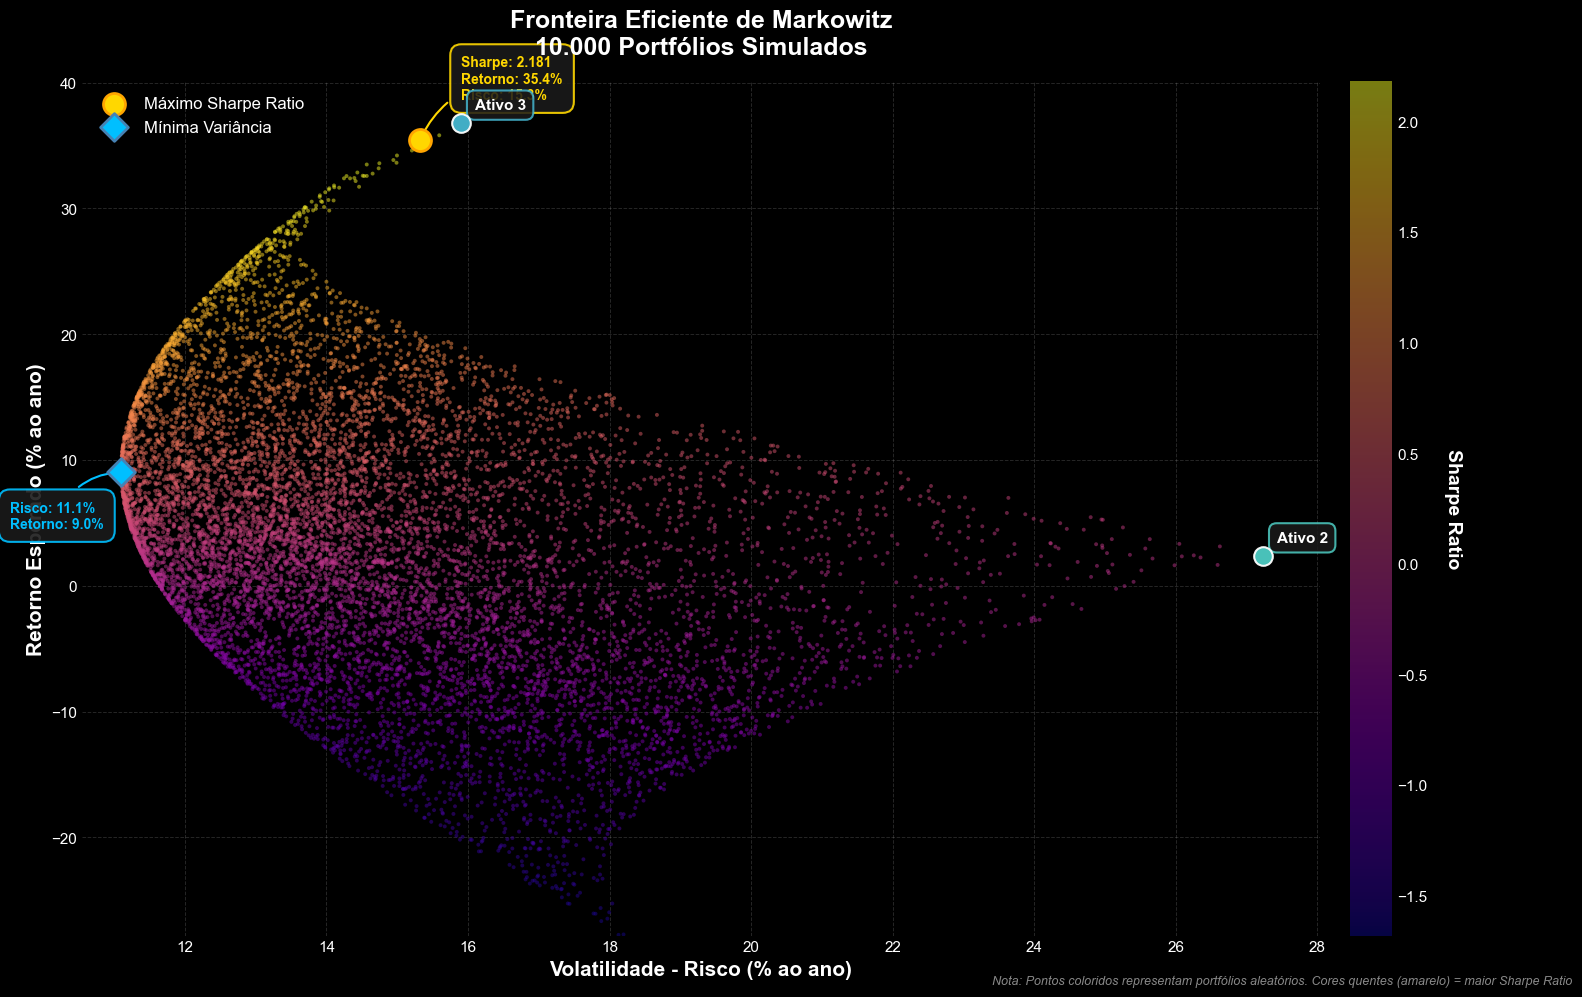

In [9]:

# Configurar estilo escuro
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(16, 10), facecolor='black')
ax.set_facecolor('black')

# Plotar todos os portfólios simulados com gradiente de cores
scatter = ax.scatter(volatilidades_simuladas * 100, 
                     retornos_simulados * 100, 
                     c=sharpe_ratios_simulados, 
                     cmap='plasma',
                     alpha=0.5, 
                     s=8,                  # Pontos menores e sutis
                     edgecolors='none')    # Sem borda nos pontos

# Colorbar customizado
cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label('Sharpe Ratio', fontsize=14, fontweight='bold', rotation=270, labelpad=25, color='white')
cbar.ax.tick_params(labelsize=11, colors='white')
cbar.outline.set_edgecolor('white')

# Destacar portfólio de Máximo Sharpe — círculo suave em vez de estrela
ax.scatter(volatilidades_simuladas[idx_max_sharpe] * 100, 
           retornos_simulados[idx_max_sharpe] * 100,
           marker='o', s=250, c='gold', edgecolors='orange', linewidths=2,
           label='Máximo Sharpe Ratio', zorder=10)

# Adicionar anotação para Máximo Sharpe
ax.annotate(f'Sharpe: {sharpe_ratios_simulados[idx_max_sharpe]:.3f}\n' + 
            f'Retorno: {retornos_simulados[idx_max_sharpe]:.1%}\n' +
            f'Risco: {volatilidades_simuladas[idx_max_sharpe]:.1%}',
            xy=(volatilidades_simuladas[idx_max_sharpe] * 100, 
                retornos_simulados[idx_max_sharpe] * 100),
            xytext=(30, 30), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.8', facecolor='
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3', color='gold', lw=1.5),
            fontsize=10, fontweight='bold', color='gold')

# Destacar portfólio de Mínima Variância — diamante suave
ax.scatter(volatilidades_simuladas[idx_min_vol] * 100, 
           retornos_simulados[idx_min_vol] * 100,
           marker='D', s=200, c='deepskyblue', edgecolors='steelblue', linewidths=2,
           label='Mínima Variância', zorder=10)

# Adicionar anotação para Mínima Variância
ax.annotate(f'Risco: {volatilidades_simuladas[idx_min_vol]:.1%}\n' +
            f'Retorno: {retornos_simulados[idx_min_vol]:.1%}',
            xy=(volatilidades_simuladas[idx_min_vol] * 100, 
                retornos_simulados[idx_min_vol] * 100),
            xytext=(-80, -40), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.8', facecolor='
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=-0.3', color='deepskyblue', lw=1.5),
            fontsize=10, fontweight='bold', color='deepskyblue')

# Plotar ativos individuais com estilo
cores_ativos = ['#FF6B6B', '#4ECDC4', '#45B7D1']
for i, (ativo, cor) in enumerate(zip(['Ativo 1', 'Ativo 2', 'Ativo 3'], cores_ativos)):
    vol_ativo = np.sqrt(Sigma.iloc[i, i]) * 100
    ret_ativo = mu.iloc[i] * 100
    ax.scatter(vol_ativo, ret_ativo, marker='o', s=180, 
               c=cor, alpha=0.95, edgecolors='white', linewidths=1.5, zorder=8)
    ax.annotate(ativo, xy=(vol_ativo, ret_ativo),
                xytext=(10, 10), textcoords='offset points',
                fontsize=11, fontweight='bold', color='white',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='

# Configurações dos eixos
ax.set_xlabel('Volatilidade - Risco (% ao ano)', fontsize=15, fontweight='bold', color='white')
ax.set_ylabel('Retorno Esperado (% ao ano)', fontsize=15, fontweight='bold', color='white')
ax.set_title('Fronteira Eficiente de Markowitz\n10.000 Portfólios Simulados', 
             fontsize=18, fontweight='bold', color='white', pad=20)

ax.tick_params(colors='white', labelsize=11)
for spine in ax.spines.values():
    spine.set_edgecolor('#444444')

# Grid sutil
ax.grid(True, alpha=0.15, linestyle='--', linewidth=0.7, color='white')
ax.set_axisbelow(True)

# Legenda customizada
legend = ax.legend(loc='upper left', fontsize=12, framealpha=0.85,
                   edgecolor='#555555', fancybox=True)
legend.get_frame().set_facecolor('#1a1a1a')
for text in legend.get_texts():
    text.set_color('white')

# Ajustar limites dos eixos
ax.set_xlim(left=volatilidades_simuladas.min() * 100 * 0.95)
ax.set_ylim(bottom=retornos_simulados.min() * 100 * 0.95)

# Nota de rodapé
fig.text(0.99, 0.01, 
         'Nota: Pontos coloridos representam portfólios aleatórios. '
         'Cores quentes (amarelo) = maior Sharpe Ratio',
         ha='right', fontsize=9, style='italic', color='#888888')

plt.tight_layout()
plt.show()

## 6. Otimização Matemática: Calculando a Fronteira Exata

Até agora usamos **simulação** (10.000 portfólios aleatórios) para *visualizar* a fronteira.

Agora vamos calcular a fronteira **EXATA** usando otimização matemática.

### O Problema de Otimização:

Para cada nível de retorno alvo $\mu_{\text{alvo}}$, queremos encontrar o portfólio de **mínimo risco**:

$$
\min_{w} \quad \frac{1}{2} w^T \Sigma w
$$

**Sujeito a:**
$$
\begin{align}
w^T \mu &= \mu_{\text{alvo}} \quad \text{(retorno desejado)} \\
w^T \mathbf{1} &= 1 \quad \text{(investir 100\%)} \\
w_i &\geq 0 \quad \text{(sem venda a descoberto)}
\end{align}
$$

### Ferramentas:

Usaremos **`scipy.optimize.minimize`** com:
- **Função objetivo:** Volatilidade do portfólio
- **Restrições de igualdade:** Retorno alvo e soma dos pesos = 1
- **Restrições de desigualdade:** Pesos ≥ 0

In [ ]:
"""
📐 IMPLEMENTAÇÃO: Otimizador de Portfólio de Markowitz

Vamos criar uma função que encontra o portfólio de mínimo risco
para um retorno alvo específico.
"""

def otimizar_portfolio(mu, Sigma, retorno_alvo):
    """
    Encontra o portfólio de MÍNIMA VARIÂNCIA para um retorno alvo.
    
    Parâmetros:
    - mu: vetor de retornos esperados (pandas Series ou numpy array)
    - Sigma: matriz de covariância (pandas DataFrame ou numpy array)
    - retorno_alvo: retorno anual desejado (float)
    
    Retorna:
    - dict com: pesos, retorno, volatilidade, sharpe
    """
    n_ativos = len(mu)
    
    # Converter para arrays NumPy se necessário
    mu_array = mu.values if hasattr(mu, 'values') else mu
    Sigma_array = Sigma.values if hasattr(Sigma, 'values') else Sigma
    
    # Função objetivo: minimizar volatilidade
    def objetivo(w):
        return volatilidade_portfolio(w, Sigma_array)
    
    # Restrições
    restricoes = [
        {
            'type': 'eq',  # Igualdade
            'fun': lambda w: np.sum(w) - 1.0
        },
        {
            'type': 'eq',
            'fun': lambda w: retorno_portfolio(w, mu_array) - retorno_alvo
        }
    ]
    
    # Limites: cada peso entre 0 e 1 (sem short selling)
    limites = tuple((0, 1) for _ in range(n_ativos))
    
    w0 = np.array([1.0 / n_ativos] * n_ativos)
    
    resultado = minimize(
        fun=objetivo,           # Função a minimizar
        x0=w0,                  # Chute inicial
        method='SLSQP',         # Sequential Least Squares Programming
        bounds=limites,         # Limites dos pesos
        constraints=restricoes, # Restrições
        options={'ftol': 1e-9, 'disp': False}
    )
    
    w_otimo = resultado.x
    
    return {
        'pesos': w_otimo,
        'retorno': retorno_portfolio(w_otimo, mu_array),
        'volatilidade': volatilidade_portfolio(w_otimo, Sigma_array),
        'sharpe': sharpe_ratio(w_otimo, mu_array, Sigma_array),
        'sucesso': resultado.success
    }


print("✅ Função de otimização criada!")
print("\nUso: otimizar_portfolio(mu, Sigma, retorno_alvo=0.12)")

In [ ]:
"""
🧪 TESTE: Vamos otimizar para um retorno alvo de 12% ao ano
"""

retorno_desejado = 0.12  # 12% ao ano

resultado_otimo = otimizar_portfolio(mu, Sigma, retorno_desejado)

print("="*70)
print(f"🎯 PORTFÓLIO OTIMIZADO PARA RETORNO DE {retorno_desejado:.1%}")
print("="*70)

if resultado_otimo['sucesso']:
    print("\n✅ Otimização bem-sucedida!\n")
    
    print("📊 RESULTADOS:")
    print(f"   Retorno esperado: {resultado_otimo['retorno']:.2%}")
    print(f"   Volatilidade: {resultado_otimo['volatilidade']:.2%}")
    print(f"   Sharpe Ratio: {resultado_otimo['sharpe']:.3f}")
    
    print("\n💼 ALOCAÇÃO ÓTIMA:")
    for i, (ativo, peso) in enumerate(zip(['Ativo_1', 'Ativo_2', 'Ativo_3'], 
                                          resultado_otimo['pesos'])):
        print(f"   {ativo}: {peso:>6.2%}")
    
    print(f"\n   TOTAL: {resultado_otimo['pesos'].sum():>6.2%}")
    
else:
    print("❌ Otimização falhou. Tente outro retorno alvo.")

print("="*70)

# Comparar com portfólio simulado mais próximo
idx_similar = np.argmin(np.abs(retornos_simulados - retorno_desejado))

print(f"\n📊 COMPARAÇÃO: Otimização vs Simulação")
print("="*70)
print(f"{'Métrica':<20} {'Otimizado':>15} {'Melhor Simulado':>20}")
print("-"*70)
print(f"{'Retorno':<20} {resultado_otimo['retorno']:>14.2%} {retornos_simulados[idx_similar]:>19.2%}")
print(f"{'Volatilidade':<20} {resultado_otimo['volatilidade']:>14.2%} {volatilidades_simuladas[idx_similar]:>19.2%}")
print(f"{'Sharpe Ratio':<20} {resultado_otimo['sharpe']:>14.3f} {sharpe_ratios_simulados[idx_similar]:>19.3f}")
print("="*70)

print("\n💡 O portfólio OTIMIZADO tem menor risco para o mesmo retorno!")
print("   Isso mostra que otimização matemática > simulação aleatória")

In [ ]:
"""
📈 CALCULAR A FRONTEIRA EFICIENTE COMPLETA

Vamos otimizar para vários níveis de retorno e traçar a curva exata.
"""

# Definir range de retornos para otimizar
retorno_min = mu.min()  # Menor retorno possível
retorno_max = mu.max()  # Maior retorno possível

# Criar 50 pontos entre o mínimo e máximo
retornos_alvo = np.linspace(retorno_min, retorno_max, 50)

# Arrays para armazenar resultados da fronteira
fronteira_retornos = []
fronteira_volatilidades = []
fronteira_sharpes = []
fronteira_pesos = []

print(f"🔄 Calculando fronteira eficiente para {len(retornos_alvo)} níveis de retorno...")
print(f"   Range: {retorno_min:.1%} até {retorno_max:.1%}\n")

# Contador de progresso
sucessos = 0
falhas = 0

for ret_alvo in retornos_alvo:
    try:
        resultado = otimizar_portfolio(mu, Sigma, ret_alvo)
        
        if resultado['sucesso']:
            fronteira_retornos.append(resultado['retorno'])
            fronteira_volatilidades.append(resultado['volatilidade'])
            fronteira_sharpes.append(resultado['sharpe'])
            fronteira_pesos.append(resultado['pesos'])
            sucessos += 1
        else:
            falhas += 1
            
    except:
        falhas += 1
        continue

# Converter para arrays
fronteira_retornos = np.array(fronteira_retornos)
fronteira_volatilidades = np.array(fronteira_volatilidades)
fronteira_sharpes = np.array(fronteira_sharpes)

print(f"✅ Fronteira calculada!")
print(f"   Sucessos: {sucessos}/{len(retornos_alvo)}")
print(f"   Falhas: {falhas}/{len(retornos_alvo)}")

# Encontrar portfólios especiais na fronteira
idx_max_sharpe_fronteira = fronteira_sharpes.argmax()
idx_min_vol_fronteira = fronteira_volatilidades.argmin()

print(f"\n📊 PORTFÓLIOS ESPECIAIS NA FRONTEIRA ÓTIMA:")
print("="*70)

print(f"\n⭐ PORTFÓLIO TANGENTE (Máximo Sharpe):")
print(f"   Retorno: {fronteira_retornos[idx_max_sharpe_fronteira]:.2%}")
print(f"   Volatilidade: {fronteira_volatilidades[idx_max_sharpe_fronteira]:.2%}")
print(f"   Sharpe: {fronteira_sharpes[idx_max_sharpe_fronteira]:.3f}")
print(f"   Alocação:")
for i, peso in enumerate(fronteira_pesos[idx_max_sharpe_fronteira]):
    print(f"      Ativo_{i+1}: {peso:.1%}")

print(f"\n🛡️ PORTFÓLIO DE MÍNIMA VARIÂNCIA GLOBAL:")
print(f"   Retorno: {fronteira_retornos[idx_min_vol_fronteira]:.2%}")
print(f"   Volatilidade: {fronteira_volatilidades[idx_min_vol_fronteira]:.2%}")
print(f"   Sharpe: {fronteira_sharpes[idx_min_vol_fronteira]:.3f}")
print(f"   Alocação:")
for i, peso in enumerate(fronteira_pesos[idx_min_vol_fronteira]):
    print(f"      Ativo_{i+1}: {peso:.1%}")

print("="*70)

In [ ]:
"""
🎨 VISUALIZAÇÃO FINAL: Fronteira Eficiente Otimizada vs Simulação
"""

plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(16, 10), facecolor='white')

# 1. Plotar portfólios simulados (fundo)
scatter = ax.scatter(volatilidades_simuladas * 100, 
                     retornos_simulados * 100, 
                     c=sharpe_ratios_simulados, 
                     cmap='plasma',
                     alpha=0.3,  # Mais transparente para não ofuscar a fronteira
                     s=15, 
                     edgecolors='none',
                     label='Portfólios Simulados (10.000)')

# 2. Plotar FRONTEIRA EFICIENTE ÓTIMA (linha grossa)
ax.plot(fronteira_volatilidades * 100, 
        fronteira_retornos * 100,
        linewidth=4, 
        color='red', 
        label='Fronteira Eficiente (Otimizada)',
        zorder=5,
        linestyle='-',
        alpha=0.9)

# 3. Destacar Portfólio Tangente (Máximo Sharpe) na fronteira
ax.scatter(fronteira_volatilidades[idx_max_sharpe_fronteira] * 100,
           fronteira_retornos[idx_max_sharpe_fronteira] * 100,
           marker='*', s=2000, c='gold', edgecolors='darkred', linewidths=4,
           label='⭐ Portfólio Tangente (Máx Sharpe)', zorder=10)

ax.annotate(f'Sharpe: {fronteira_sharpes[idx_max_sharpe_fronteira]:.3f}\n' + 
            f'Retorno: {fronteira_retornos[idx_max_sharpe_fronteira]:.1%}\n' +
            f'Risco: {fronteira_volatilidades[idx_max_sharpe_fronteira]:.1%}',
            xy=(fronteira_volatilidades[idx_max_sharpe_fronteira] * 100, 
                fronteira_retornos[idx_max_sharpe_fronteira] * 100),
            xytext=(40, 40), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=1', facecolor='gold', alpha=0.9, edgecolor='darkred', linewidth=3),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3', color='darkred', lw=3),
            fontsize=11, fontweight='bold', zorder=11)

# 4. Destacar Mínima Variância Global na fronteira
ax.scatter(fronteira_volatilidades[idx_min_vol_fronteira] * 100,
           fronteira_retornos[idx_min_vol_fronteira] * 100,
           marker='D', s=800, c='deepskyblue', edgecolors='navy', linewidths=4,
           label='🛡️ Mínima Variância Global', zorder=10)

ax.annotate(f'Risco Mínimo: {fronteira_volatilidades[idx_min_vol_fronteira]:.1%}\n' +
            f'Retorno: {fronteira_retornos[idx_min_vol_fronteira]:.1%}',
            xy=(fronteira_volatilidades[idx_min_vol_fronteira] * 100, 
                fronteira_retornos[idx_min_vol_fronteira] * 100),
            xytext=(-100, -50), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=1', facecolor='deepskyblue', alpha=0.9, edgecolor='navy', linewidth=3),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=-0.3', color='navy', lw=3),
            fontsize=11, fontweight='bold', zorder=11)

# 5. Plotar ativos individuais
cores_ativos = ['#FF6B6B', '#4ECDC4', '#45B7D1']
for i, (ativo, cor) in enumerate(zip(['Ativo 1', 'Ativo 2', 'Ativo 3'], cores_ativos)):
    vol_ativo = np.sqrt(Sigma.iloc[i, i]) * 100
    ret_ativo = mu.iloc[i] * 100
    ax.scatter(vol_ativo, ret_ativo, marker='s', s=500, 
               c=cor, alpha=0.95, edgecolors='black', linewidths=3, zorder=8)
    ax.annotate(ativo, xy=(vol_ativo, ret_ativo),
                xytext=(12, 12), textcoords='offset points',
                fontsize=12, fontweight='bold', color='white',
                bbox=dict(boxstyle='round,pad=0.6', facecolor=cor, alpha=0.95, 
                         edgecolor='black', linewidth=2))

# 6. Adicionar linha da taxa livre de risco (Capital Market Line)
rf_rate = 0.02  # 2% ao ano
# Linha que sai da taxa livre de risco e toca o portfólio tangente
cml_x = np.array([0, fronteira_volatilidades[idx_max_sharpe_fronteira] * 100 * 1.5])
cml_slope = (fronteira_retornos[idx_max_sharpe_fronteira] - rf_rate) / fronteira_volatilidades[idx_max_sharpe_fronteira]
cml_y = rf_rate * 100 + cml_slope * cml_x

ax.plot(cml_x, cml_y, 'g--', linewidth=2.5, alpha=0.7, 
        label=f'Capital Market Line (rf={rf_rate:.0%})', zorder=6)

# Colorbar
cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label('Sharpe Ratio', fontsize=14, fontweight='bold', rotation=270, labelpad=25)
cbar.ax.tick_params(labelsize=11)

# Configurações finais
ax.set_xlabel('Volatilidade - Risco (% ao ano)', fontsize=16, fontweight='bold', color='
ax.set_ylabel('Retorno Esperado (% ao ano)', fontsize=16, fontweight='bold', color='
ax.set_title('🏆 Fronteira Eficiente de Markowitz\nOtimização Matemática vs Simulação Monte Carlo', 
             fontsize=18, fontweight='bold', color='#2C3E50', pad=25)

ax.grid(True, alpha=0.3, linestyle='--', linewidth=1)
ax.set_axisbelow(True)

legend = ax.legend(loc='upper left', fontsize=11, framealpha=0.95, 
                   edgecolor='black', fancybox=True, shadow=True)
legend.get_frame().set_facecolor('white')

fig.text(0.99, 0.01, 
         '📊 Linha vermelha = portfólios matematicamente ótimos | ' +
         'Pontos coloridos = simulação aleatória',
         ha='right', fontsize=9, style='italic', color='gray')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("🎯 CONCLUSÕES PRINCIPAIS".center(80))
print("="*80)
print("\n1️⃣ FRONTEIRA EFICIENTE (linha vermelha):")
print("   • Conjunto de todos os portfólios ótimos")
print("   • Para cada nível de risco, oferece o MÁXIMO retorno possível")
print("   • Para cada nível de retorno, oferece o MÍNIMO risco possível")

print("\n2️⃣ PORTFÓLIO TANGENTE (estrela dourada):")
print("   • Melhor relação risco-retorno (maior Sharpe Ratio)")
print("   • Ponto onde a Capital Market Line toca a fronteira")
print("   • Este é o portfólio 'ideal' segundo a teoria moderna")

print("\n3️⃣ MÍNIMA VARIÂNCIA GLOBAL (losango azul):")
print("   • Portfólio mais conservador possível")
print("   • Menor risco entre TODOS os portfólios")
print("   • Ideal para investidores muito avessos a risco")

print("\n4️⃣ DIVERSIFICAÇÃO:")
print("   • Note que portfólios na fronteira têm MENOS risco que ativos individuais!")
print("   • Combinar ativos correlacionados negativamente reduz risco total")
print("   • 'Free lunch' da teoria de portfólio")

print("\n5️⃣ OTIMIZAÇÃO vs SIMULAÇÃO:")
print("   • Fronteira calculada > portfólios aleatórios")
print("   • Matemática garante encontrar os verdadeiros ótimos")
print("="*80)